# Capstone Project 3: Dialogue Summarization (SAMSum)

## Problem Statement and Approach
Information overload in very active group chats reduces user engagement and makes it harder to catch up after being away. A summary feature can condense long dialogue threads into short, accurate summaries that capture the key points in the conversation. In this project, we use the SAMSum dataset, dialogues paired with summaries, to build a prototype that converts a dialogue into a brief summary.  

## Problem Description
The input is a multi-turn dialogue from a group chat.  The output will be a concise summary that preserves the important facts and agreements and other key points.  The goal is to demonstrate that an encoder–decoder transformer can reliably generate summaries suitable for a user-facing product feature.  

## Approach  
The project will follow an end-to-end NLP workflow: data exploration, then work on preprocessing and tokenization, then model design (BERT-based encoder–decoder), followed by fine tuning and evaluation with ROUGE, finally we will assess our error analysis and make improvements.  


## Import Libraries and Data

In [ ]:
!pip install -q transformers datasets accelerate evaluate rouge-score

In [13]:
# Environment Setup

import os
import re
import math
import json
import random
from dataclasses import dataclass
from pathlib import Path

import numpy as np
import pandas as pd

import torch

import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

# Transformers
from transformers import ( AutoTokenizer, EncoderDecoderModel, DataCollatorForSeq2Seq, Seq2SeqTrainingArguments, Seq2SeqTrainer, EarlyStoppingCallback, )
from transformers import set_seed

# Metrics (ROUGE)
import evaluate

# Paths (Subfolder is Data, the three files are train.csv, validation.csv, and test.csv)

PROJECT_DIR = Path.cwd()
DATA_DIR = PROJECT_DIR / "Data"

TRAIN_PATH = DATA_DIR / "train.csv"
VAL_PATH = DATA_DIR / "validation.csv"
TEST_PATH = DATA_DIR / "test.csv"

assert TRAIN_PATH.exists(), f"Missing: {TRAIN_PATH}"
assert VAL_PATH.exists(), f"Missing: {VAL_PATH}"
assert TEST_PATH.exists(), f"Missing: {TEST_PATH}"

# Reproducibility
SEED = 42
set_seed(SEED)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("DEVICE:", DEVICE)

#Dev Mode
DEV_MODE = True
MAX_TRAIN_SAMPLES = 1000 if DEV_MODE else None
MAX_VAL_SAMPLES = 500 if DEV_MODE else None
MAX_TEST_SAMPLES = 500 if DEV_MODE else None

# Tokenization / sequence length params (you will tune after EDA)

ENC_MAX_LEN = 256 # encoder (dialogue) max length
DEC_MAX_LEN = 64 # decoder (summary) max length

# Generation params (baseline)
GEN_NUM_BEAMS = 4
GEN_LENGTH_PENALTY = 1.0
GEN_MAX_LENGTH = DEC_MAX_LEN
GEN_NO_REPEAT_NGRAM_SIZE = 3

DEVICE: cpu


In [14]:
# Load data & basic validation
train_df = pd.read_csv(TRAIN_PATH)
val_df = pd.read_csv(VAL_PATH)
test_df = pd.read_csv(TEST_PATH)

print("Train:", train_df.shape, "Val:", val_df.shape, "Test:", test_df.shape)
print("Columns:", train_df.columns.tolist())

# Basic missing values check
print("\nMissing values (train):")
print(train_df.isna().sum())

# Basic sample preview
print("\nSample train row:")
display(train_df.head(1))

#Optional subset for dev mode
if DEV_MODE: train_df = train_df.sample(n=min(MAX_TRAIN_SAMPLES, len(train_df)), random_state=SEED).reset_index(drop=True)
val_df = val_df.sample(n=min(MAX_VAL_SAMPLES, len(val_df)), random_state=SEED).reset_index(drop=True)
test_df = test_df.sample(n=min(MAX_TEST_SAMPLES, len(test_df)), random_state=SEED).reset_index(drop=True)

print("\nAfter DEV_MODE subsetting:")
print("Train:", train_df.shape, "Val:", val_df.shape, "Test:", test_df.shape)


Train: (14731, 3) Val: (818, 3) Test: (819, 3)
Columns: ['id', 'dialogue', 'summary']

Missing values (train):
id          0
dialogue    0
summary     0
dtype: int64

Sample train row:


,id,dialogue,summary
0,13818513,Amanda: I baked cookies. Do you want some?\nJ...,Amanda baked cookies and will bring Jerry some...



After DEV_MODE subsetting:
Train: (1000, 3) Val: (500, 3) Test: (500, 3)


Train dialogue word count summary:
count    1000.000000
mean       94.246000
std        78.059995
min         7.000000
25%        39.000000
50%        72.500000
75%       128.000000
max       612.000000
Name: dialogue_words, dtype: float64

Train summary word count summary:
count    1000.000000
mean       20.098000
std        11.002065
min         3.000000
25%        12.000000
50%        18.000000
75%        26.000000
max        58.000000
Name: summary_words, dtype: float64


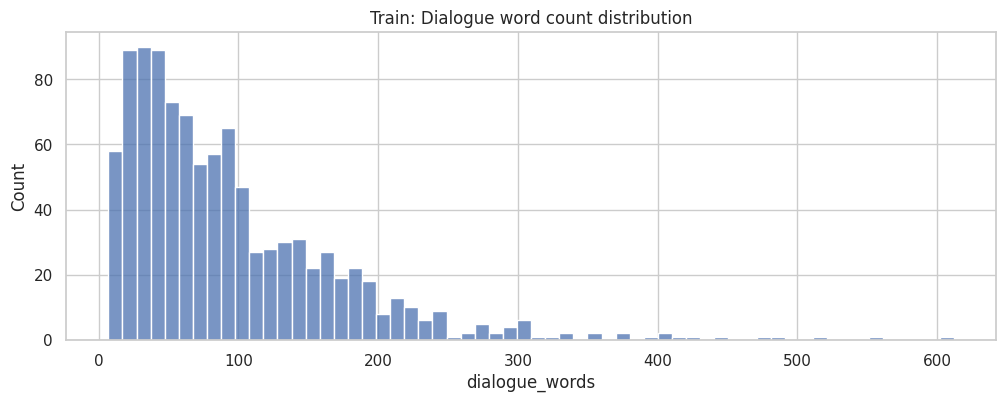

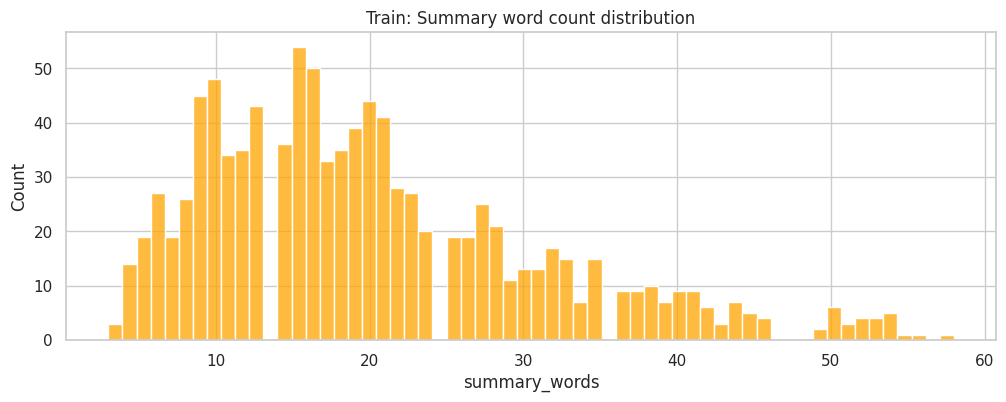

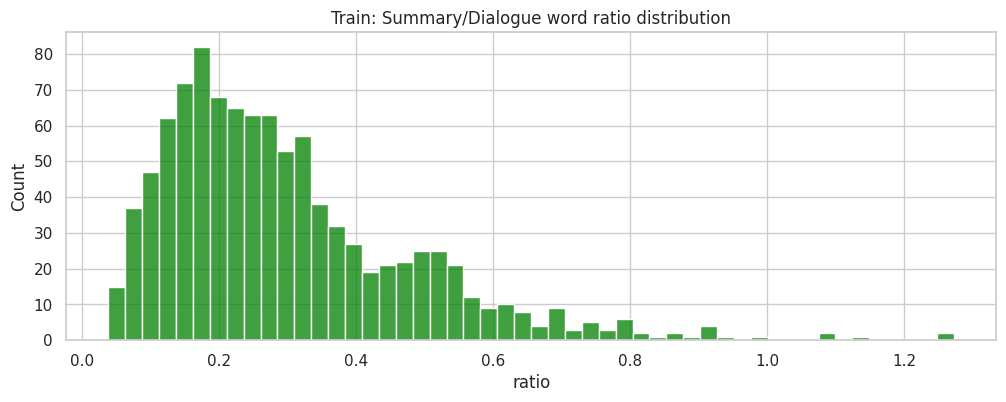


Longest dialogues (train):


,id,dialogue,summary,dialogue_words,summary_words
848,13828862,"Robin: Appologies, it really irks me\nOlive: F...",Robin had an argument with a female colleague ...,612,50
607,13816865-1,"John: Hey, James. found accommodation?\nJames:...",John and James are looking for accommodation n...,553,54
571,13612225,Carly: so tell me about yr holidays....drunk a...,Andy was on holiday. Carly suggests that they ...,517,34



Shortest summaries (train):


,id,dialogue,summary,dialogue_words,summary_words
88,13682608,Uma: did u make groceries?\nRodney: yes\nUma: ...,Rodney made groceries.,10,3
176,13730577,Sam: hey Zoya\nZoya: Hii ^_^\nSam: happy birth...,It's Zoya's birthday.,15,3
251,13863129,"Harold: hi, I've heard you learn japanese?\nPh...",Phil's learning Japanese.,60,3


In [15]:
# EDA: word-length distributions, summary ratio, sanity checks
def word_count(x: str) -> int:
    x = "" if pd.isna(x) else str(x)
    x = x.replace("\n", " ")
    toks = [t for t in x.split(" ") if t.strip()]
    return len(toks)

# Dialogue word count & summary word count
train_df["dialogue_words"] = train_df["dialogue"].astype(str).apply(word_count)
train_df["summary_words"] = train_df["summary"].astype(str).apply(word_count)
train_df["ratio"] = train_df["summary_words"] / train_df["dialogue_words"].replace(0, np.nan)

val_df["dialogue_words"] = val_df["dialogue"].astype(str).apply(word_count)
val_df["summary_words"] = val_df["summary"].astype(str).apply(word_count)
val_df["ratio"] = val_df["summary_words"] / val_df["dialogue_words"].replace(0, np.nan)

print("Train dialogue word count summary:")
print(train_df["dialogue_words"].describe())
print("\nTrain summary word count summary:")
print(train_df["summary_words"].describe())

# Plot distributions
sns.set(style="whitegrid")

plt.figure(figsize=(12,4))
sns.histplot(train_df["dialogue_words"], bins=60, kde=False)
plt.title("Train: Dialogue word count distribution")
plt.show()

plt.figure(figsize=(12,4))
sns.histplot(train_df["summary_words"], bins=60, kde=False, color="orange")
plt.title("Train: Summary word count distribution")
plt.show()

plt.figure(figsize=(12,4))
sns.histplot(train_df["ratio"].dropna(), bins=50, kde=False, color="green")
plt.title("Train: Summary/Dialogue word ratio distribution")
plt.show()

# Show a couple examples with extremely long dialogues or short summaries (helps truncation decisions)
print("\nLongest dialogues (train):")
display(train_df.sort_values("dialogue_words", ascending=False).head(3)[["id","dialogue","summary","dialogue_words","summary_words"]])

print("\nShortest summaries (train):")
display(train_df.sort_values("summary_words", ascending=True).head(3)[["id","dialogue","summary","dialogue_words","summary_words"]])

## The following section is designed to normalize speaker markers to reduce token noise

1) Replace "Name:" / "A:" / "B:" speaker prefixes with a generic "SPEAKER:"
2) Replace any <...> markup tokens (e.g. <file_gif>) with a stable token "[MARKUP]"
3) Normalize whitespace

In [16]:
# Preprocessing: normalize speakers & replace noisy markup tokens

SPEAKER_PREFIX_RE = re.compile(r"(?m)^\s*([A-Za-z][A-Za-z0-9_-])\s:\s*") # start-of-line "X:" (common speaker label pattern)
MARKUP_RE = re.compile(r"<[^>]+>") # anything like <file_gif>

def normalize_dialogue(text: str) -> str:
    if pd.isna(text):
        return ""
    text = str(text)

# Replace speaker labels with generic token
    text = SPEAKER_PREFIX_RE.sub("SPEAKER: ", text)

# Replace markup tokens with a stable placeholder
    text = MARKUP_RE.sub("[MARKUP]", text)

# Normalize whitespace
    text = text.replace("\r", "\n")
    text = text.replace("\n", "\n")
    text = re.sub(r"[ \t]+", " ", text)
    text = re.sub(r"\n\s+", "\n", text)
    text = text.strip()

    return text

In [17]:
def normalize_summary(text: str) -> str:
        if pd.isna(text):
            return ""
        text = str(text)
        text = text.replace("\r", " ")
        text = re.sub(r"\s+", " ", text).strip()
        return text

train_df["dialogue_clean"] = train_df["dialogue"].astype(str).apply(normalize_dialogue)
train_df["summary_clean"] = train_df["summary"].astype(str).apply(normalize_summary)

val_df["dialogue_clean"] = val_df["dialogue"].astype(str).apply(normalize_dialogue)
val_df["summary_clean"] = val_df["summary"].astype(str).apply(normalize_summary)

test_df["dialogue_clean"] = test_df["dialogue"].astype(str).apply(normalize_dialogue)
test_df["summary_clean"] = test_df["summary"].astype(str).apply(normalize_summary)

print("Before/after example (dialogue):")
ex_i = 0
display(train_df.loc[ex_i, ["dialogue", "dialogue_clean"]])

print("\nBefore/after example (summary):")
display(train_df.loc[ex_i, ["summary", "summary_clean"]])

Before/after example (dialogue):


,0
dialogue,Violet: hi! i came across this Austin's articl...
dialogue_clean,Violet: hi! i came across this Austin's articl...



Before/after example (summary):


,0
summary,Violet sent Claire Austin's article.
summary_clean,Violet sent Claire Austin's article.


In [18]:
# Token-length stats require a tokenizer
print("\nLoading tokenizer for token-length analysis...")

tokenizer_name = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(tokenizer_name, use_fast=True)

def count_tokens(text: str) -> int: # We only want length estimates; no truncation/padding here.
    return len(tokenizer.encode(text, add_special_tokens=True))

train_df["dialogue_tokens"] = train_df["dialogue_clean"].apply(count_tokens)
train_df["summary_tokens"] = train_df["summary_clean"].apply(count_tokens)

print("\nToken count stats (train):")
print("Dialogue tokens:", train_df["dialogue_tokens"].describe())
print("Summary tokens :", train_df["summary_tokens"].describe())


Loading tokenizer for token-length analysis...

Token count stats (train):
Dialogue tokens: count    1000.00000
mean      136.54300
std       106.57513
min        14.00000
25%        59.00000
50%       108.00000
75%       183.00000
max       797.00000
Name: dialogue_tokens, dtype: float64
Summary tokens : count    1000.000000
mean       27.079000
std        13.659112
min         6.000000
25%        17.000000
50%        24.000000
75%        34.000000
max        77.000000
Name: summary_tokens, dtype: float64


Dialogue token 90th percentile: 276.0
Summary token 90th percentile: 47.0
----
Dialogue token 95th percentile: 333.0999999999999
Summary token 95th percentile: 54.0
----
Dialogue token 97th percentile: 392.2399999999998
Summary token 97th percentile: 61.02999999999997
----
Dialogue token 99th percentile: 525.0699999999999
Summary token 99th percentile: 68.0
----


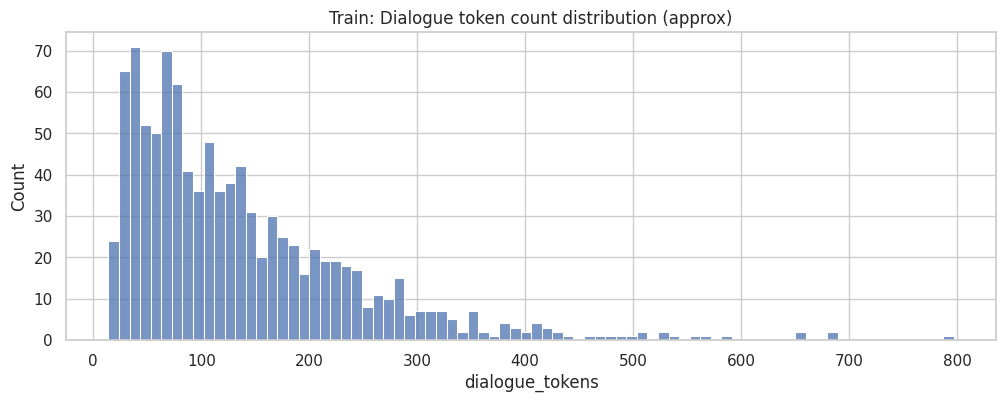

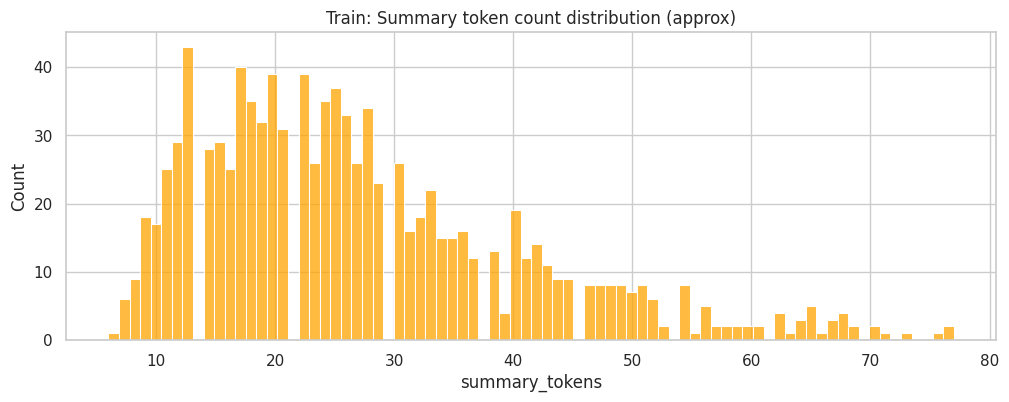

Suggested ENC_MAX_LEN: 333
Suggested DEC_MAX_LEN: 54


In [19]:
# Max lengths by percentile coverage
for p in [90, 95, 97, 99]:
    print(f"Dialogue token {p}th percentile:", np.percentile(train_df["dialogue_tokens"], p))
    print(f"Summary token {p}th percentile:", np.percentile(train_df["summary_tokens"], p))
    print("----")

plt.figure(figsize=(12,4))
sns.histplot(train_df["dialogue_tokens"], bins=80, kde=False)
plt.title("Train: Dialogue token count distribution (approx)")
plt.show()

plt.figure(figsize=(12,4))
sns.histplot(train_df["summary_tokens"], bins=80, kde=False, color="orange")
plt.title("Train: Summary token count distribution (approx)")
plt.show()

print("Suggested ENC_MAX_LEN:", int(np.percentile(train_df["dialogue_tokens"], 95)))
print("Suggested DEC_MAX_LEN:", int(np.percentile(train_df["summary_tokens"], 95)))

In [20]:
# Lead-k extractive baseline & ROUGE evaluation
# In the pitch for this project, these were the tools referenced

rouge = evaluate.load("rouge")

def split_into_sentences(dialogue: str): # Simple sentence segmentation. (Dataset lines may use speaker turns; still helps.)
    # If a dialogue is multiline, this treats punctuation as boundaries.
    dialogue = dialogue.replace("\n", " ").strip()
    parts = re.split(r'(?<=[.!?])\s+', dialogue)
    parts = [p.strip() for p in parts if p.strip()]
    return parts

def lead_k_summary(dialogue_clean: str, k: int = 3) -> str:
    sents = split_into_sentences(dialogue_clean)
    chosen = sents[:k]
    if len(chosen) == 0:
        return ""
    return " ".join(chosen)

def rouge_eval_texts(pred_texts, ref_texts):
    # Use ROUGE F1 (evaluate returns precision/recall/fmeasure)
    # We'll compute with stemming enabled for stability.
    results = rouge.compute(predictions=pred_texts, references=ref_texts, use_stemmer=True)
    # results keys typically: rouge1, rouge2, rougeL
    return results

def evaluate_lead_k_on_df(df, k: int = 3):
    preds = [lead_k_summary(d, k=k) for d in df["dialogue_clean"].tolist()]
    refs = df["summary_clean"].tolist()
    results = rouge_eval_texts(preds, refs)
    return results, preds

Lead-3 baseline ROUGE on validation:
{'rouge1': np.float64(0.3109808112471461), 'rouge2': np.float64(0.09979138752341842), 'rougeL': np.float64(0.2402184323284407), 'rougeLsum': np.float64(0.2409332964593336)}

Qualitative baseline examples (val):


,id,dialogue_sample,pred_lead_k,reference_summary
0,13814873,Betty: Running late! Missed my bus :(\nHarriet...,Betty: Running late! Missed my bus :( Harriet:...,Betty will be late. Harriet will leave her tic...
1,13681385,Callum: [MARKUP]\nSaanvi: Hahahha finally I se...,Callum: [MARKUP] Saanvi: Hahahha finally I see...,Callum's picture shows him when he is smiling ...
2,13611675,"Alice: Good evening, Professor, I apologize fo...","Alice: Good evening, Professor, I apologize fo...",Margaret is going to teach her classes tomorro...
3,13821332,"Ian: David, are you ok?\nDavid: yes, I am, no ...","Ian: David, are you ok? David: yes, I am, no w...",David was safe when the tsunami hit.
4,13864653,Lena: Do you know who discovered vitamins?\nMa...,Lena: Do you know who discovered vitamins? Mar...,"According to Wikipedia, vitamins were discover..."


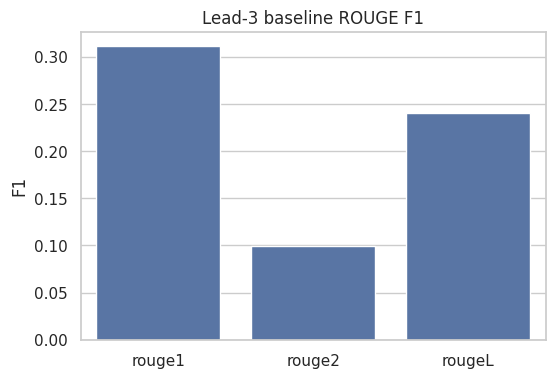

In [21]:
# Evaluate baseline on validation
LEAD_K = 3
baseline_results, baseline_preds = evaluate_lead_k_on_df(val_df, k=LEAD_K)

print(f"Lead-{LEAD_K} baseline ROUGE on validation:")
print(baseline_results)

# Create a small qualitative table
print("\nQualitative baseline examples (val):")
show_n = 5
idxs = np.random.choice(len(val_df),
                       size=min(show_n, len(val_df)),
                       replace=False)

rows = []
for i in idxs:
    # Check if baseline_preds is a list/array or a single value
    if isinstance(baseline_preds, (list, np.ndarray)) and len(baseline_preds) > i:
        pred_text = baseline_preds[i][:200]
    else:
        # If baseline_preds is a scalar or doesn't have enough elements, use it directly
        pred_text = str(baseline_preds)[:200]

    rows.append({
        "id": val_df.iloc[i]["id"],
        "dialogue_sample": str(val_df.iloc[i]["dialogue_clean"])[:120] + "...",
        "pred_lead_k": pred_text,  # Fixed: handle both scalar and array cases
        "reference_summary": val_df.iloc[i]["summary_clean"][:200],
    })

display(pd.DataFrame(rows))

# Plot ROUGE (baseline single-point bar chart)
labels = ["rouge1", "rouge2", "rougeL"]
f1s = [baseline_results[l] for l in labels]

plt.figure(figsize=(6,4))
sns.barplot(x=labels, y=f1s)
plt.title(f"Lead-{LEAD_K} baseline ROUGE F1")
plt.ylabel("F1")
plt.show()

In [22]:
import warnings

import torch
from transformers import EncoderDecoderModel, GenerationConfig
from transformers.utils import logging as hf_logging

hf_logging.set_verbosity_error()
warnings.filterwarnings("ignore", category=UserWarning, message=r".*as_target_tokenizer is deprecated.*")

model = EncoderDecoderModel.from_encoder_decoder_pretrained(tokenizer_name, tokenizer_name)

# For BERT:
# CLS as decoder start and beginning of sequence token
# SEP as EOS (common choice for BERT-family)
model.config.decoder_start_token_id = tokenizer.cls_token_id
model.config.bos_token_id = tokenizer.cls_token_id # Explicitly setting bos_token_id
model.config.eos_token_id = tokenizer.sep_token_id
model.config.pad_token_id = tokenizer.pad_token_id

# Ensure generation_config is updated with the special token IDs
if hasattr(model, 'generation_config') and model.generation_config is not None:
    model.generation_config.decoder_start_token_id = model.config.decoder_start_token_id
    model.generation_config.bos_token_id = model.config.bos_token_id
    model.generation_config.eos_token_id = model.config.eos_token_id
    model.generation_config.pad_token_id = model.config.pad_token_id
else:
    # If generation_config doesn't exist, create it from the updated model.config
    model.generation_config = GenerationConfig.from_model_config(model.config)

model.to(DEVICE)


# Tokenization for seq2seq
def preprocess_function(examples):
    # Encoder inputs
    model_inputs = tokenizer(
        examples["dialogue_clean"],
        max_length=ENC_MAX_LEN,
        padding="max_length",
        truncation=True,
    )

    # Decoder labels
    labels = tokenizer(
        examples["summary_clean"],
        max_length=DEC_MAX_LEN,
        padding="max_length",
        truncation=True,
    )

    model_inputs["labels"] = labels["input_ids"]
    return model_inputs


# HuggingFace dataset-like formatting

class SimpleDataset(torch.utils.data.Dataset):

    def __init__(self, df):
        self.df = df.reset_index(drop=True)

        # Pre-tokenize once (faster training later)
        enc = preprocess_function({
            "dialogue_clean": self.df["dialogue_clean"].tolist(),
            "summary_clean": self.df["summary_clean"].tolist(),
        })

        self.input_ids = torch.tensor(enc["input_ids"], dtype=torch.long)
        self.attention_mask = torch.tensor(enc["attention_mask"], dtype=torch.long)
        self.labels = torch.tensor(enc["labels"], dtype=torch.long)

        # Replace padding token id in labels with -100 so loss ignores them
        self.labels[self.labels == tokenizer.pad_token_id] = -100

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        return {
            "input_ids": self.input_ids[idx],
            "attention_mask": self.attention_mask[idx],
            "labels": self.labels[idx],
        }


train_dataset = SimpleDataset(train_df)
val_dataset = SimpleDataset(val_df)

print("Train dataset size:", len(train_dataset), "Val dataset size:", len(val_dataset))

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

Train dataset size: 1000 Val dataset size: 500


In [24]:
def decode_batch_ids(token_ids_batch): # token_ids_batch: numpy array or list # Replace -100 with pad for decoding
    token_ids_batch = np.array(token_ids_batch)
    token_ids_batch = np.where(token_ids_batch == -100, tokenizer.pad_token_id, token_ids_batch)
    texts = tokenizer.batch_decode(token_ids_batch, skip_special_tokens=True, clean_up_tokenization_spaces=True) # Strip extra whitespace
    texts = [t.strip() for t in texts]
    return texts

def postprocess_generation(texts): # Optional: you can do extra cleanup here
    return [t.strip() for t in texts]

def compute_metrics(eval_pred):
    # Extract predictions and labels from the EvalPrediction object
    preds, labels = eval_pred.predictions, eval_pred.label_ids

    # Ensure predictions are integer token IDs.
    if preds.dtype == np.float32 or preds.dtype == np.float64:
        preds = preds.astype(np.int64)

    # Safeguard against out-of-range token IDs generated by an unstable model.
    # Replace any values that are negative or exceed the tokenizer's vocabulary size
    # with the pad_token_id to prevent OverflowError during decoding.
    preds[preds < 0] = tokenizer.pad_token_id
    preds[preds >= tokenizer.vocab_size] = tokenizer.pad_token_id

    # Decode predictions - use preds instead of undefined pred_ids
    texts = tokenizer.batch_decode(preds, skip_special_tokens=True, clean_up_tokenization_spaces=True)

    # Process the decoded texts - use texts instead of undefined pred_texts
    pred_texts = postprocess_generation([t.strip() for t in texts])
    label_texts = decode_batch_ids(labels)

    results = rouge.compute(
        predictions=pred_texts,
        references=label_texts,
        use_stemmer=True
    )
    # Trainer expects a flat dict of floats for logging
    return {
        "rouge1_f": results["rouge1"],
        "rouge2_f": results["rouge2"],
        "rougeL_f": results["rougeL"],
    }

# Training args (with early stopping/checkpointing)
output_dir = str(PROJECT_DIR / "outputs_seq2seq_bert_encoder_decoder")

training_args = Seq2SeqTrainingArguments(
    output_dir=output_dir,
    eval_strategy="epoch",
    save_strategy="epoch",

# Training hyperparams — choose conservative defaults; tune later
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    gradient_accumulation_steps=1,

    learning_rate=3e-5,
    num_train_epochs=3 if DEV_MODE else 10,
    weight_decay=0.01,

    warmup_steps=0,
    lr_scheduler_type="linear",

    #fp16=torch.cuda.is_available(),  # mixed precision if GPU

    predict_with_generate=True,
    generation_max_length=GEN_MAX_LENGTH,

    logging_steps=25,
    save_total_limit=2,

    load_best_model_at_end=True,
    metric_for_best_model="rougeL_f",
    greater_is_better=True,

    seed=SEED,
    dataloader_num_workers=0,

    remove_unused_columns=True,  # This filters out unexpected parameters

    dataloader_drop_last=False,
)

# Updated data collator with minimal parameters to avoid conflicts
data_collator = DataCollatorForSeq2Seq(
    tokenizer=tokenizer,
    model=model,
    padding=True,
    return_tensors="pt"
)

early_stopping = EarlyStoppingCallback(early_stopping_patience=2)

trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[early_stopping],
)

print("Starting training...")
train_result = trainer.train()
print("Training finished.")

print("\nBest metric (Trainer):")
print(trainer.state.best_metric)


Starting training...


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
/usr/local/lib/python3.12/dist-packages/transformers/models/encoder_decoder/modeling_encoder_decoder.py:445: FutureWarning: Version v4.12.0 introduces a better way to train encoder-decoder models by computing the loss inside the encoder-decoder framework rather than in the decoder itself. You may observe training discrepancies if fine-tuning a model trained with versions anterior to 4.12.0. The decoder_input_ids are now created based on the labels, no need to pass them yourself anymore.
  warnings.warn(DEPRECATION_WARNING, FutureWarning)


{'loss': '4.474', 'grad_norm': '14.3', 'learning_rate': '2.904e-05', 'epoch': '0.1'}
{'loss': '4.367', 'grad_norm': '13.06', 'learning_rate': '2.804e-05', 'epoch': '0.2'}
{'loss': '4.211', 'grad_norm': '16.39', 'learning_rate': '2.704e-05', 'epoch': '0.3'}
{'loss': '4.009', 'grad_norm': '16.03', 'learning_rate': '2.604e-05', 'epoch': '0.4'}
{'loss': '4.004', 'grad_norm': '16.83', 'learning_rate': '2.504e-05', 'epoch': '0.5'}
{'loss': '3.894', 'grad_norm': '17.84', 'learning_rate': '2.404e-05', 'epoch': '0.6'}
{'loss': '3.719', 'grad_norm': '20.01', 'learning_rate': '2.304e-05', 'epoch': '0.7'}
{'loss': '3.779', 'grad_norm': '27.16', 'learning_rate': '2.204e-05', 'epoch': '0.8'}
{'loss': '3.657', 'grad_norm': '19.04', 'learning_rate': '2.104e-05', 'epoch': '0.9'}
{'loss': '3.825', 'grad_norm': '19.73', 'learning_rate': '2.004e-05', 'epoch': '1'}
{'eval_loss': '4.35', 'eval_rouge1_f': '0.1482', 'eval_rouge2_f': '0.02183', 'eval_rougeL_f': '0.1324', 'eval_runtime': '1334', 'eval_samples_p

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
/usr/local/lib/python3.12/dist-packages/transformers/models/encoder_decoder/modeling_encoder_decoder.py:445: FutureWarning: Version v4.12.0 introduces a better way to train encoder-decoder models by computing the loss inside the encoder-decoder framework rather than in the decoder itself. You may observe training discrepancies if fine-tuning a model trained with versions anterior to 4.12.0. The decoder_input_ids are now created based on the labels, no need to pass them yourself anymore.
  warnings.warn(DEPRECATION_WARNING, FutureWarning)


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
/usr/local/lib/python3.12/dist-packages/transformers/models/encoder_decoder/modeling_encoder_decoder.py:445: FutureWarning: Version v4.12.0 introduces a better way to train encoder-decoder models by computing the loss inside the encoder-decoder framework rather than in the decoder itself. You may observe training discrepancies if fine-tuning a model trained with versions anterior to 4.12.0. The decoder_input_ids are now created based on the labels, no need to pass them yourself anymore.
  warnings.warn(DEPRECATION_WARNING, FutureWarning)


{'loss': '3.332', 'grad_norm': '17.68', 'learning_rate': '9.04e-06', 'epoch': '2.1'}
{'loss': '3.295', 'grad_norm': '18.67', 'learning_rate': '8.04e-06', 'epoch': '2.2'}
{'loss': '3.141', 'grad_norm': '15.57', 'learning_rate': '7.04e-06', 'epoch': '2.3'}
{'loss': '3.065', 'grad_norm': '15.64', 'learning_rate': '6.04e-06', 'epoch': '2.4'}
{'loss': '3.198', 'grad_norm': '13.96', 'learning_rate': '5.04e-06', 'epoch': '2.5'}
{'loss': '3.225', 'grad_norm': '14.29', 'learning_rate': '4.04e-06', 'epoch': '2.6'}
{'loss': '3.137', 'grad_norm': '16.41', 'learning_rate': '3.04e-06', 'epoch': '2.7'}
{'loss': '3.163', 'grad_norm': '16.83', 'learning_rate': '2.04e-06', 'epoch': '2.8'}
{'loss': '3.138', 'grad_norm': '15.57', 'learning_rate': '1.04e-06', 'epoch': '2.9'}
{'loss': '3.145', 'grad_norm': '18.51', 'learning_rate': '4e-08', 'epoch': '3'}
{'eval_loss': '4.239', 'eval_rouge1_f': '0.1641', 'eval_rouge2_f': '0.03042', 'eval_rougeL_f': '0.1419', 'eval_runtime': '1390', 'eval_samples_per_second':

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'train_runtime': '1.749e+04', 'train_samples_per_second': '0.172', 'train_steps_per_second': '0.043', 'train_loss': '3.62', 'epoch': '3'}
Training finished.

Best metric (Trainer):
0.14315472612205365


In [26]:
# Inference with beam search, evaluate ROUGE, qualitative examples & error analysis

# Get predictions on validation for qualitative analysis
gen_kwargs = dict(
    num_beams=GEN_NUM_BEAMS, # Corrected key
    length_penalty=GEN_LENGTH_PENALTY, # Corrected key
    max_length=GEN_MAX_LENGTH, # Corrected key
    early_stopping=True,
    no_repeat_ngram_size=GEN_NO_REPEAT_NGRAM_SIZE, # Corrected key
)

# Collect generated summaries
val_preds = []
val_refs  = val_df["summary_clean"].tolist() # Corrected variable name

model.eval()

# Generate in batches for speed
batch_size = 8
with torch.no_grad():
    for start in range(0, len(val_dataset), batch_size): # Corrected batch_size
        end = min(start + batch_size, len(val_dataset)) # Corrected batch_size
        batch = [val_dataset[i] for i in range(start, end)]
        input_ids = torch.stack([b["input_ids"] for b in batch]).to(DEVICE) # Corrected argument name
        attention_mask = torch.stack([b["attention_mask"] for b in batch]).to(DEVICE) # Corrected argument name

        generated_ids = model.generate(
            input_ids=input_ids, # Corrected argument name
            attention_mask=attention_mask, # Corrected argument name
            **gen_kwargs # Unpacked the dictionary
        )

        texts = tokenizer.batch_decode(generated_ids, skip_special_tokens=True, clean_up_tokenization_spaces=True)
        texts = [t.strip() for t in texts]
        val_preds.extend(texts)

# Compute ROUGE on generated validation summaries
val_results = rouge_eval_texts(val_preds, val_refs) # Corrected function name and variable name
print(f"Model (beam={GEN_NUM_BEAMS}, length_penalty={GEN_LENGTH_PENALTY}) ROUGE on validation:")
print(val_results)


Model (beam=4, length_penalty=1.0) ROUGE on validation:
{'rouge1': np.float64(0.1741778699501026), 'rouge2': np.float64(0.03304037931768247), 'rougeL': np.float64(0.14679966947533024), 'rougeLsum': np.float64(0.14694842629398924)}


,rouge1f,rouge2f,rougeLf
lead-3,0.310981,0.099791,0.240218
seq2seq-model,0.174178,0.033040,0.146800


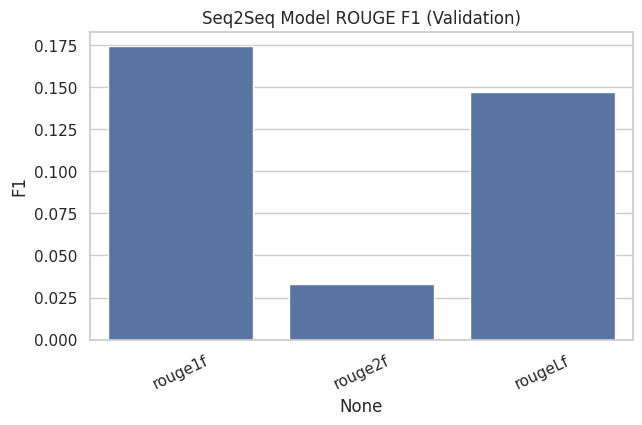

In [28]:
# Compare baseline vs model
baseline_f = {
    "rouge1f": baseline_results["rouge1"],
    "rouge2f": baseline_results["rouge2"],
    "rougeLf": baseline_results["rougeL"],
}
model_f = {
    "rouge1f": val_results["rouge1"],
    "rouge2f": val_results["rouge2"],
    "rougeLf": val_results["rougeL"],
}
comparedf = pd.DataFrame([baseline_f, model_f], index=[f"lead-{LEAD_K}", "seq2seq-model"])
display(comparedf)

plt.figure(figsize=(7,4))
sns.barplot(x=comparedf.columns, y=comparedf.loc["seq2seq-model"].values)
plt.title("Seq2Seq Model ROUGE F1 (Validation)")
plt.ylabel("F1")
plt.xticks(rotation=25)
plt.show()

In [32]:
# Qualitative examples: best ROUGE and worst ROUGE
# Compute per-example ROUGE by calling rouge on single pairs.
# Working in DEV_MODE, val is limited; so this is fine.
def rouge_single(pred, ref):
    r = rouge.compute(predictions=[pred], references=[ref], use_stemmer=True)
    return r # Corrected: Directly return the dictionary of scores

perexscores = []
for i in range(len(val_df)):
    sc = rouge_single(val_preds[i], val_refs[i])
    perexscores.append(sc)

rougeLscores = [sc["rougeL"] for sc in perexscores]
besti = int(np.argmax(rougeLscores))
worsti = int(np.argmin(rougeLscores))

def show_example(i, title):
    print("\n" + title)
    print("-"*len(title))
    display(pd.DataFrame([{
        "id": val_df.iloc[i]["id"],
        "dialogue": val_df.iloc[i]["dialogue_clean"][:250] + "...",
        "predictedsummary": val_preds[i],
        "referencesummary": val_refs[i],
        "rouge1f": perexscores[i]["rouge1"],
        "rouge2f": perexscores[i]["rouge2"],
        "rougeLf": perexscores[i]["rougeL"],
    }]))

show_example(besti, "BEST (by ROUGE-L)")
show_example(worsti, "WORST (by ROUGE-L)")

print("\nRandom qualitative samples:")
for _ in range(3):
    i = int(np.random.randint(0, len(val_df)))
    show_example(i, f"Sample idx={i}")



BEST (by ROUGE-L)
-----------------


,id,dialogue,predictedsummary,referencesummary,rouge1f,rouge2f,rougeLf
0,13820116,Tom: who's going to be at the party tonight\nP...,mike is going to the party tonight.,Tom wonders who is going to the party tonight.,0.75,0.714286,0.75



WORST (by ROUGE-L)
------------------


,id,dialogue,predictedsummary,referencesummary,rouge1f,rouge2f,rougeLf
0,13729340,"Tom: U OK?\nAlex: Yeah, pretty good. U?\nTom: ...","mike is drunk drunk. he was drunk drunk drunk,...",Tom and Alex had fun last night. They drank a ...,0.0,0.0,0.0



Random qualitative samples:

Sample idx=102
--------------


,id,dialogue,predictedsummary,referencesummary,rouge1f,rouge2f,rougeLf
0,13828602,Morgan: Juliaaaa :)\nMorgan: How are u dear??\...,lisa is going to the party.,Julia is at work. She will meet Morgan for a d...,0.086957,0.0,0.086957



Sample idx=435
--------------


,id,dialogue,predictedsummary,referencesummary,rouge1f,rouge2f,rougeLf
0,13865083,Fred: I quit my job so I would be happy if you...,mike is looking for a job job at work. he is n...,Fred quit his job because of mobbing. Kathy an...,0.235294,0.125,0.176471



Sample idx=348
--------------


,id,dialogue,predictedsummary,referencesummary,rouge1f,rouge2f,rougeLf
0,13727839,Madison: Hello Lawrence are you through with t...,ben will be in the morning tomorrow.,Lawrence will finish writing the article soon.,0.285714,0.0,0.285714


In [35]:
tuning_grid = [
    {"beam": 2, "len_pen": 0.8},
    {"beam": 4, "len_pen": 1.0},
    {"beam": 6, "len_pen": 1.1},
]
maxlengths = [DEC_MAX_LEN]  # optionally try [DEC_MAX_LEN-8, DEC_MAX_LEN, DEC_MAX_LEN+8]

results_rows = []

# For speed, tune on a small subset of validation in DEV_MODE
tunesubset = min(len(val_df), 150) if DEV_MODE else len(val_df)

val_df_tune = val_df.iloc[:tunesubset].reset_index(drop=True)

# Create a small dataset slice (reusing preprocessing already done)
val_dataset_tune = SimpleDataset(val_df_tune)

with torch.no_grad():
    # Generate for each configuration
    for cfg in tuning_grid:
        for ml in maxlengths:
            gen_kwargs_local = dict(
                num_beams=cfg["beam"],
                length_penalty=cfg["len_pen"],
                max_length=ml,
                early_stopping=True,
                no_repeat_ngram_size=GEN_NO_REPEAT_NGRAM_SIZE,
            )

            preds_local = []
            refs_local  = val_df_tune["summary_clean"].tolist()

            batch_size = 8
            for start in range(0, len(val_dataset_tune), batch_size):
                end = min(start + batch_size, len(val_dataset_tune))
                batch = [val_dataset_tune[i] for i in range(start, end)]
                input_ids = torch.stack([b["input_ids"] for b in batch]).to(DEVICE)
                attention_mask = torch.stack([b["attention_mask"] for b in batch]).to(DEVICE)

                generated_ids = model.generate(
                    input_ids=input_ids,
                    attention_mask=attention_mask,
                    **gen_kwargs_local
                )

                texts = tokenizer.batch_decode(generated_ids, skip_special_tokens=True, clean_up_tokenization_spaces=True)
                texts = [t.strip() for t in texts]
                preds_local.extend(texts)

            res_local = rouge_eval_texts(preds_local, refs_local)

            results_rows.append({
                "beam": cfg["beam"],
                "length_penalty": cfg["len_pen"],
                "max_length": ml,
                "rouge1f": res_local["rouge1"],
                "rouge2f": res_local["rouge2"],
                "rougeLf": res_local["rougeL"],
            })
            print("Done:", results_rows[-1])

tuning_results_df = pd.DataFrame(results_rows).sort_values("rougeLf", ascending=False)
display(tuning_results_df)

Done: {'beam': 2, 'length_penalty': 0.8, 'max_length': 64, 'rouge1f': np.float64(0.1699208376307178), 'rouge2f': np.float64(0.02765288783474707), 'rougeLf': np.float64(0.14665842831442366)}
Done: {'beam': 4, 'length_penalty': 1.0, 'max_length': 64, 'rouge1f': np.float64(0.17748444837442096), 'rouge2f': np.float64(0.02889428557709143), 'rougeLf': np.float64(0.15232221790235195)}
Done: {'beam': 6, 'length_penalty': 1.1, 'max_length': 64, 'rouge1f': np.float64(0.17673464961905094), 'rouge2f': np.float64(0.026409236491540533), 'rougeLf': np.float64(0.14841893264570535)}


,beam,length_penalty,max_length,rouge1f,rouge2f,rougeLf
1,4,1.0,64,0.177484,0.028894,0.152322
2,6,1.1,64,0.176735,0.026409,0.148419
0,2,0.8,64,0.169921,0.027653,0.146658


In [37]:
# Reproducibility checklist

bestcfg = tuning_results_df.iloc[0].to_dict() if len(tuning_results_df) else {}
print("\nBest decoding config found on tune subset:")
display(pd.DataFrame([bestcfg]))


Best decoding config found on tune subset:


,beam,length_penalty,max_length,rouge1f,rouge2f,rougeLf
0,4.0,1.0,64.0,0.177484,0.028894,0.152322


In [39]:
# Final inference examples (test set)

test_preds = []
testrefs = test_df["summary_clean"].tolist() if "summary_clean" in test_df.columns else None

testdataset = SimpleDataset(test_df)

model.eval()
with torch.no_grad():
    batch_size = 8
    for start in range(0, len(testdataset), batch_size):
        end = min(start + batch_size, len(testdataset))
        batch = [testdataset[i] for i in range(start, end)]
        input_ids = torch.stack([b["input_ids"] for b in batch]).to(DEVICE)
        attention_mask = torch.stack([b["attention_mask"] for b in batch]).to(DEVICE)

        gen_kwargs_final = dict(
            num_beams=int(bestcfg.get("beam", GEN_NUM_BEAMS)),
            length_penalty=float(bestcfg.get("len_pen", GEN_LENGTH_PENALTY)),
            max_length=int(bestcfg.get("max_length", GEN_MAX_LENGTH)),
            early_stopping=True,
            no_repeat_ngram_size=GEN_NO_REPEAT_NGRAM_SIZE,
        )

        generated_ids = model.generate(
            input_ids=input_ids,
            attention_mask=attention_mask,
            **gen_kwargs_final
        )

        texts = tokenizer.batch_decode(generated_ids, skip_special_tokens=True, clean_up_tokenization_spaces=True)
        texts = [t.strip() for t in texts]
        test_preds.extend(texts)

print("\nTest inference sample outputs:")
show_n = 8
idxs = np.random.choice(len(test_df), size=min(show_n, len(test_df)), replace=False)

rows = []
for i in idxs:
    rows.append({
        "id": test_df.iloc[i]["id"],
        "predictedsummary": test_preds[i][:250],
        "referencesummary": testrefs[i][:250] if testrefs is not None else None,
    })
display(pd.DataFrame(rows))


Test inference sample outputs:


,id,predictedsummary,referencesummary
0,13864490,kate is looking for a new one. she can't affor...,Kate broke her arm and she's going to the hosp...
1,13821268,mia is going to the party. mia is happy.,Allison has got a scholarship.
2,13680442,mary is going to the airport. she can't afford...,Linda refuses to accept plants for her garden ...
3,13810132,mike and mike are going to meet at the cinema....,Imagine Dragons have a concert at ABC Theatre ...
4,13729524,mike is going to the concert. he can't wait.,Jim will check out Max's latest music project ...
5,13729313,mike and mike are going to meet at 7 pm. they ...,Margaret and Evans plan to meet at 10 on 4th a...
6,13729790,chris and chris will go to the games tomorrow....,luke and martial want to help the team and pla...
7,13828681,mike has a problem with his head. he's going t...,Maxwell pays Jeanice for 8 hours of babysittin...
